<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/Coding_vs_NonCoding_Region_Finder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coding vs Non-Coding Region Finder

**Objective:** Given a DNA sequence, identify putative coding regions (ORFs), count coding and non-coding regions, and list their coordinates, sequences, lengths, and translated proteins.

> **Important:** From DNA sequence alone, we cannot definitively label every segment as biologically coding or non-coding. This notebook uses an **ORF-based prediction**: an ORF starts with `ATG`, ends with an in-frame stop codon (`TAA`, `TAG`, `TGA`), and meets a user-defined minimum length. Everything outside the predicted ORFs is reported as non-coding **by this rule**.
What the notebook does
Accepts a DNA sequence directly in Colab
Removes FASTA headers/whitespace
Searches all six reading frames
Identifies putative ORFs using:
Start codon: ATG
Stop codons: TAA, TAG, TGA
User-defined minimum ORF length
Reports:
Coding region number
Start and end coordinates
Length
DNA sequence
Reading frame
Strand
Start/stop codons
Translated amino-acid sequence
Merges overlapping ORFs into coding intervals
Identifies the remaining intervals as non-coding by the ORF-based criterion
Counts coding vs non-coding regions
Calculates nucleotide percentages
Produces a sequence annotation visualization
Exports four CSV files


In [1]:
#@title 1. Enter DNA sequence and parameters

DNA_SEQUENCE = """ATGAAACCCGGGTTTAAACCCATGCGTACGTAGCTAGCTAAACCGGTTAATGCCCGGGTAGCCCTGA""" #@param {type:"string"}
MIN_ORF_NT = 30 #@param {type:"integer"}

MIN_ORF_NT = max(3, MIN_ORF_NT - (MIN_ORF_NT % 3))

def clean_dna(seq):
    seq = ''.join(line.strip() for line in seq.splitlines()
                  if not line.startswith('>'))
    return seq.upper().replace(' ', '').replace('\n', '')

dna = clean_dna(DNA_SEQUENCE)
invalid = sorted(set(dna) - set("ACGTN"))

print("Sequence length:", len(dna), "nt")
print("Sequence:", dna)

if invalid:
    raise ValueError(f"Invalid nucleotide characters: {invalid}")


Sequence length: 67 nt
Sequence: ATGAAACCCGGGTTTAAACCCATGCGTACGTAGCTAGCTAAACCGGTTAATGCCCGGGTAGCCCTGA


## 2. Find ORFs in all six reading frames

The notebook scans the three forward frames and three reverse-complement frames. An ORF begins at `ATG` and terminates at the first in-frame stop codon.


In [2]:
from collections import defaultdict
import pandas as pd

STOP_CODONS = {"TAA", "TAG", "TGA"}

def reverse_complement(seq):
    table = str.maketrans("ACGTN", "TGCAN")
    return seq.translate(table)[::-1]

def find_orfs(seq, strand_label):
    records = []

    for frame in range(3):
        open_starts = []

        for i in range(frame, len(seq) - 2, 3):
            codon = seq[i:i+3]

            if codon == "ATG":
                open_starts.append(i)

            if codon in STOP_CODONS and open_starts:
                start = open_starts[0]
                end = i + 3
                length = end - start

                if length >= MIN_ORF_NT:
                    records.append({
                        "strand": strand_label,
                        "frame": frame + 1,
                        "start": start + 1,
                        "end": end,
                        "length_nt": length,
                        "sequence": seq[start:end],
                        "start_codon": seq[start:start+3],
                        "stop_codon": codon
                    })

                # First in-frame stop terminates the ORF.
                open_starts = []

    return records

forward_orfs = find_orfs(dna, "+")
rc = reverse_complement(dna)
reverse_orfs_rc = find_orfs(rc, "-")

# Convert reverse-complement coordinates to original-sequence coordinates.
n = len(dna)
reverse_orfs = []

for r in reverse_orfs_rc:
    r2 = r.copy()
    r2["start"] = n - r["end"] + 1
    r2["end"] = n - r["start"] + 1
    r2["sequence"] = reverse_complement(r["sequence"])
    reverse_orfs.append(r2)

orfs = sorted(
    forward_orfs + reverse_orfs,
    key=lambda x: (x["start"], x["end"], x["strand"])
)

if orfs:
    orf_df = pd.DataFrame(orfs)
    display(orf_df)
else:
    orf_df = pd.DataFrame(columns=[
        "strand","frame","start","end","length_nt",
        "sequence","start_codon","stop_codon"
    ])
    print("No ORFs found using minimum length:", MIN_ORF_NT, "nt")


,strand,frame,start,end,length_nt,sequence,start_codon,stop_codon
0,+,1,1,33,33,ATGAAACCCGGGTTTAAACCCATGCGTACGTAG,ATG,TAG


## 3. Translate the predicted coding candidates

The standard genetic code is used. The terminal stop codon is represented by `*`.


In [3]:
CODON_TABLE = {
    "TTT":"F","TTC":"F","TTA":"L","TTG":"L",
    "TCT":"S","TCC":"S","TCA":"S","TCG":"S",
    "TAT":"Y","TAC":"Y","TAA":"*","TAG":"*",
    "TGT":"C","TGC":"C","TGA":"*","TGG":"W",
    "CTT":"L","CTC":"L","CTA":"L","CTG":"L",
    "CCT":"P","CCC":"P","CCA":"P","CCG":"P",
    "CAT":"H","CAC":"H","CAA":"Q","CAG":"Q",
    "CGT":"R","CGC":"R","CGA":"R","CGG":"R",
    "ATT":"I","ATC":"I","ATA":"I","ATG":"M",
    "ACT":"T","ACC":"T","ACA":"T","ACG":"T",
    "AAT":"N","AAC":"N","AAA":"K","AAG":"K",
    "AGT":"S","AGC":"S","AGA":"R","AGG":"R",
    "GTT":"V","GTC":"V","GTA":"V","GTG":"V",
    "GCT":"A","GCC":"A","GCA":"A","GCG":"A",
    "GAT":"D","GAC":"D","GAA":"E","GAG":"E",
    "GGT":"G","GGC":"G","GGA":"G","GGG":"G"
}

def translate(seq):
    return "".join(
        CODON_TABLE.get(seq[i:i+3], "X")
        for i in range(0, len(seq)-2, 3)
    )

if len(orf_df):
    orf_df["protein"] = orf_df["sequence"].apply(translate)
    display(orf_df[
        ["strand","frame","start","end","length_nt","sequence","protein"]
    ])


,strand,frame,start,end,length_nt,sequence,protein
0,+,1,1,33,33,ATGAAACCCGGGTTTAAACCCATGCGTACGTAG,MKPGFKPMRT*


## 4. Merge overlapping ORFs into coding intervals

Overlapping ORFs are merged so that the same nucleotide is not counted twice. All sequence outside these intervals is classified as non-coding **by the ORF-based rule**.


In [4]:
def merge_intervals(intervals):
    if not intervals:
        return []

    intervals = sorted(intervals)
    merged = [list(intervals[0])]

    for start, end in intervals[1:]:
        if start <= merged[-1][1] + 1:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])

    return [tuple(x) for x in merged]

def complement_intervals(n, coding):
    noncoding = []
    cursor = 1

    for start, end in coding:
        if cursor < start:
            noncoding.append((cursor, start - 1))
        cursor = max(cursor, end + 1)

    if cursor <= n:
        noncoding.append((cursor, n))

    return noncoding

coding_intervals = merge_intervals([
    (int(r.start), int(r.end)) for r in orf_df.itertuples()
])

noncoding_intervals = complement_intervals(len(dna), coding_intervals)

coding_df = pd.DataFrame([
    {
        "region": f"Coding_{i}",
        "start": start,
        "end": end,
        "length_nt": end - start + 1,
        "sequence": dna[start-1:end]
    }
    for i, (start, end) in enumerate(coding_intervals, 1)
])

noncoding_df = pd.DataFrame([
    {
        "region": f"NonCoding_{i}",
        "start": start,
        "end": end,
        "length_nt": end - start + 1,
        "sequence": dna[start-1:end]
    }
    for i, (start, end) in enumerate(noncoding_intervals, 1)
])

print("CODING REGIONS")
display(coding_df if len(coding_df) else
        pd.DataFrame({"message":["No coding intervals detected."]}))

print("NON-CODING REGIONS")
display(noncoding_df if len(noncoding_df) else
        pd.DataFrame({"message":["No non-coding intervals detected."]}))


CODING REGIONS


,region,start,end,length_nt,sequence
0,Coding_1,1,33,33,ATGAAACCCGGGTTTAAACCCATGCGTACGTAG


NON-CODING REGIONS


,region,start,end,length_nt,sequence
0,NonCoding_1,34,67,34,CTAGCTAAACCGGTTAATGCCCGGGTAGCCCTGA


In [5]:
#@title 5. Final counts and summary

coding_count = len(coding_df)
noncoding_count = len(noncoding_df)

coding_nt = int(coding_df["length_nt"].sum()) if coding_count else 0
noncoding_nt = int(noncoding_df["length_nt"].sum()) if noncoding_count else 0

summary = pd.DataFrame({
    "Category": ["Coding", "Non-coding", "Total"],
    "Number_of_regions": [
        coding_count,
        noncoding_count,
        coding_count + noncoding_count
    ],
    "Total_nt": [coding_nt, noncoding_nt, len(dna)],
    "Percentage_of_sequence": [
        100 * coding_nt / len(dna) if dna else 0,
        100 * noncoding_nt / len(dna) if dna else 0,
        100.0 if dna else 0
    ]
})

display(summary)

print(f"Number of coding regions: {coding_count}")
print(f"Number of non-coding regions: {noncoding_count}")
print(f"Total sequence length: {len(dna)} nt")


,Category,Number_of_regions,Total_nt,Percentage_of_sequence
0,Coding,1,33,49.253731
1,Non-coding,1,34,50.746269
2,Total,2,67,100.000000


Number of coding regions: 1
Number of non-coding regions: 1
Total sequence length: 67 nt


## 6. Visualize coding vs non-coding sequence

The plot shows the genomic coordinates of the predicted coding intervals and the remaining sequence.


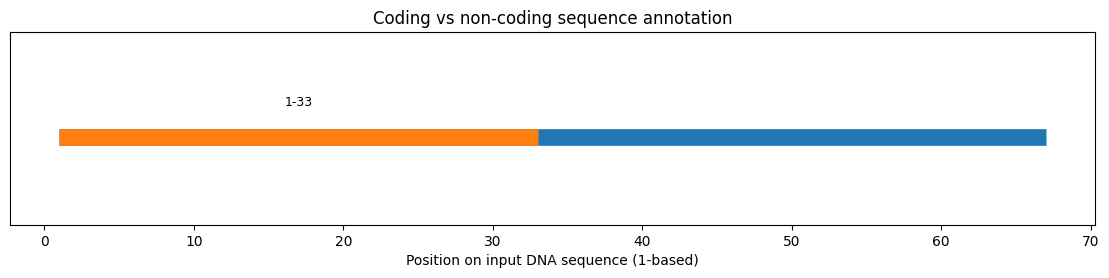

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 2.5))

ax.plot(
    [1, len(dna)], [0, 0],
    linewidth=12,
    solid_capstyle="butt"
)

for start, end in coding_intervals:
    ax.plot(
        [start, end], [0, 0],
        linewidth=12,
        solid_capstyle="butt"
    )
    ax.text(
        (start + end) / 2, 0.08,
        f"{start}-{end}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_ylim(-0.25, 0.3)
ax.set_yticks([])
ax.set_xlabel("Position on input DNA sequence (1-based)")
ax.set_title("Coding vs non-coding sequence annotation")

plt.show()


## 7. Export results

The following CSV files will be generated:

- `predicted_ORFs.csv`
- `coding_regions.csv`
- `noncoding_regions.csv`
- `coding_noncoding_summary.csv`


In [7]:
orf_df.to_csv("predicted_ORFs.csv", index=False)
coding_df.to_csv("coding_regions.csv", index=False)
noncoding_df.to_csv("noncoding_regions.csv", index=False)
summary.to_csv("coding_noncoding_summary.csv", index=False)

print("Files created successfully.")


Files created successfully.


## 8. Student interpretation questions

1. How many ORFs were detected?
2. How many coding regions were obtained after merging overlaps?
3. Which coding region is the longest?
4. What percentage of the sequence was classified as coding?
5. Why can an ORF-based method produce false-positive coding regions?
6. Why is identifying true gene structure from genomic DNA more difficult than simply finding `ATG` and stop codons?
7. How would the analysis change for a eukaryotic genomic sequence containing introns?
8. Compare the result with a reference annotation such as RefSeq, Ensembl, or GENCODE.
